In [ ]:
!pip install --only-binary :all: yfinance

In [48]:
!pip install multitasking==0.0.11


[notice] A new release of pip available: 22.1.2 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [7]:
ticker = "SPY"
raw = yf.download(ticker, start="2015-01-01", end="2026-01-01", auto_adjust=False, progress=False) 
raw.head()

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,SPY,SPY,SPY,SPY,SPY,SPY
Date,,,,,,
2015-01-02,169.687775,205.429993,206.880005,204.179993,206.380005,121465900
2015-01-05,166.623322,201.720001,204.369995,201.350006,204.169998,169632600
2015-01-06,165.053879,199.820007,202.720001,198.860001,202.089996,209151400
2015-01-07,167.110703,202.309998,202.720001,200.880005,201.419998,125346700
2015-01-08,170.076096,205.899994,206.160004,203.990005,204.009995,147217800


In [8]:
raw.shape

(2766, 6)

In [9]:
raw.columns

MultiIndex([('Adj Close', 'SPY'),
            (    'Close', 'SPY'),
            (     'High', 'SPY'),
            (      'Low', 'SPY'),
            (     'Open', 'SPY'),
            (   'Volume', 'SPY')],
           names=['Price', 'Ticker'])

In [10]:
raw.index.min(), raw.index.max()

(Timestamp('2015-01-02 00:00:00'), Timestamp('2025-12-31 00:00:00'))

In [11]:
raw.isna().sum

<bound method NDFrame._add_numeric_operations.<locals>.sum of Price      Adj Close  Close   High    Low   Open Volume
Ticker           SPY    SPY    SPY    SPY    SPY    SPY
Date                                                   
2015-01-02     False  False  False  False  False  False
2015-01-05     False  False  False  False  False  False
2015-01-06     False  False  False  False  False  False
2015-01-07     False  False  False  False  False  False
2015-01-08     False  False  False  False  False  False
...              ...    ...    ...    ...    ...    ...
2025-12-24     False  False  False  False  False  False
2025-12-26     False  False  False  False  False  False
2025-12-29     False  False  False  False  False  False
2025-12-30     False  False  False  False  False  False
2025-12-31     False  False  False  False  False  False

[2766 rows x 6 columns]>

In [12]:
prices = raw["Adj Close"].copy()
prices.head()

Ticker,SPY
Date,
2015-01-02,169.687775
2015-01-05,166.623322
2015-01-06,165.053879
2015-01-07,167.110703
2015-01-08,170.076096


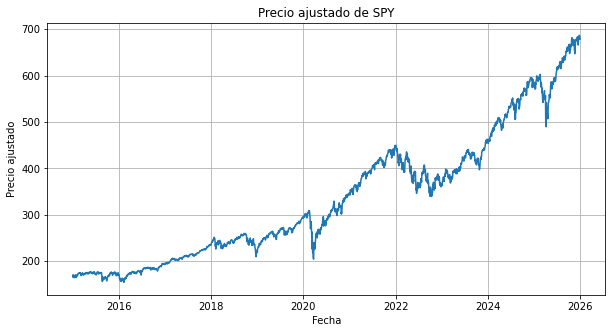

In [13]:
plt.figure(figsize=(10, 5))
plt.plot(prices)
plt.title("Precio ajustado de SPY")
plt.xlabel("Fecha")
plt.ylabel("Precio ajustado")
plt.grid(True)
plt.show()

In [14]:
log_returns = np.log(prices / prices.shift(1)).dropna()
log_returns.head()

Ticker,SPY
Date,
2015-01-05,-0.018224
2015-01-06,-0.009464
2015-01-07,0.012385
2015-01-08,0.017589
2015-01-09,-0.008046


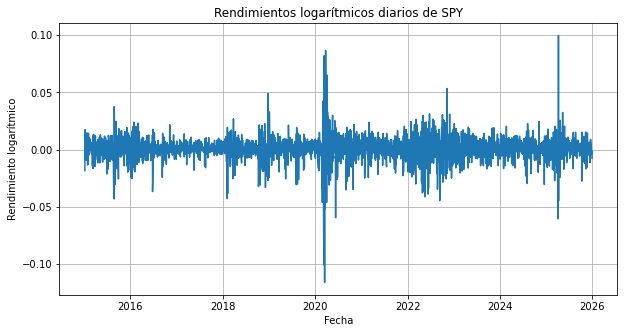

In [15]:
plt.figure(figsize=(10, 5))
plt.plot(log_returns)
plt.title("Rendimientos logarítmicos diarios de SPY")
plt.xlabel("Fecha")
plt.ylabel("Rendimiento logarítmico")
plt.grid(True)
plt.show()

# Estadística descriptiva básica


MAGALY BENAVIDES SANTIAGO

In [43]:
media= log_returns.mean()
desviacion= log_returns.std()
minimo= log_returns.min()
maximo= log_returns.max()
mediana= log_returns.median()
print('La media es:', media)
print("La desviación estándar es:", desviacion)
print("mínimo es:", minimo)
print('máximo es', maximo)
print('mediana es', mediana)


La media es: Ticker
SPY    0.000501
dtype: float64
La desviación estándar es: Ticker
SPY    0.011232
dtype: float64
mínimo es: Ticker
SPY   -0.115887
dtype: float64
máximo es Ticker
SPY    0.099863
dtype: float64
mediana es Ticker
SPY    0.000637
dtype: float64


¿La media de los rendimientos está cerca de cero?
Sí, es decir, que las ganancias se contrarrestan entre sí casi por completo. 

# INTERPRETACIÓN DE LA DESVIACIÓN ESTÁNDAR

In [25]:
Volatilidad_anualizada= desviacion*np.sqrt(252)
print("La volatilidad anualizada es", Volatilidad_anualizada)

La volatilidad anualizada es Ticker
SPY    0.178309
dtype: float64


¿Cuál es la volatilidad anualizada aproximada del activo?
Tenemos el 17.83% , nos dice que el comportamiento del activo encaja en el índice histórico. Es decir, tiene un activo moderado

# Días con mayor caída 

In [35]:
peores_dias=log_returns.sort_values(by='SPY', ascending=True)
print('Los 10 días con rendimientos más negativos', peores_dias.head(10))

Los 10 días con rendimientos más negativos Ticker           SPY
Date                
2020-03-16 -0.115887
2020-03-12 -0.100569
2020-03-09 -0.081313
2025-04-04 -0.060327
2020-06-11 -0.059377
2020-03-18 -0.051960
2025-04-03 -0.050536
2020-03-11 -0.049977
2020-04-01 -0.046049
2020-02-27 -0.045951


¿En qué fechas ocurrieron las mayores caídas del activo?
Las peores caidas ocurrieron en marzo del 2020 (específicamente el 16), abril del 2025 y junio del 2020.

# Días con mayor subida

In [45]:
mejores_dias=log_returns.sort_values(by='SPY', ascending=False)
print('Los 10 días con rendimientos más positivos', mejores_dias.head(10))

Los 10 días con rendimientos más positivos Ticker           SPY
Date                
2025-04-09  0.099863
2020-03-24  0.086731
2020-03-13  0.082028
2020-04-06  0.065007
2020-03-26  0.056749
2022-11-10  0.053498
2020-03-17  0.052585
2020-03-10  0.050451
2018-12-26  0.049290
2020-03-02  0.042395


# Histograma de rendimientos 

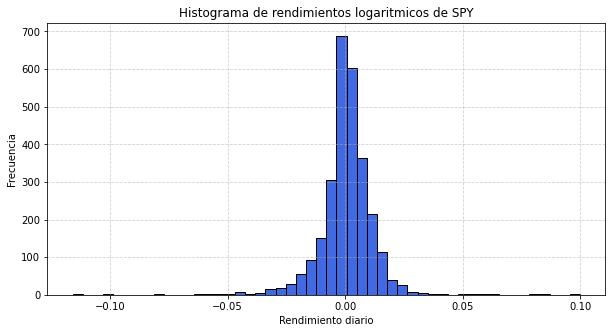

In [41]:
plt.figure(figsize=(10, 5))
plt.hist(log_returns['SPY'],bins=50, color='royalblue', edgecolor='black')
plt.title("Histograma de rendimientos logaritmicos de SPY")
plt.xlabel('Rendimiento diario')
plt.ylabel('Frecuencia')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

 ¿La mayoría de los rendimientos se concentra cerca de cero?
Sí, la gráfica muestra una campana de Gauss con distribución normal, es decir que el mercado apenas se movió algunas fracciones. 

# Comparación entre precio y rendimientos 

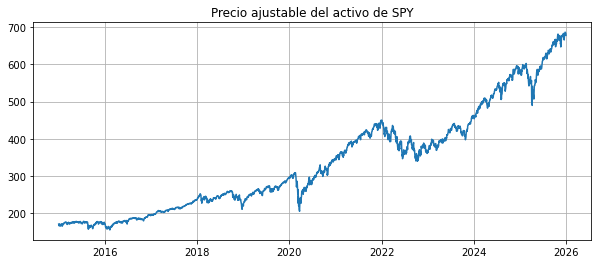

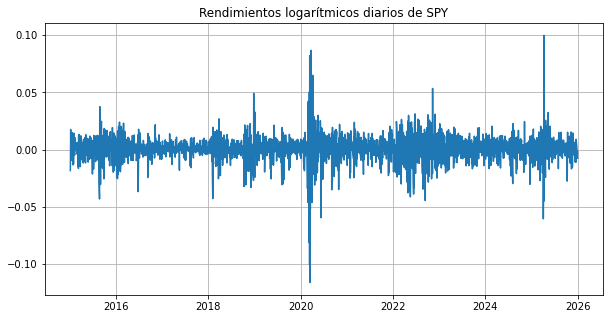

In [42]:
plt.figure(figsize=(10,4))
plt.plot(raw["Adj Close"])
plt.title("Precio ajustable del activo de SPY")
plt.grid(True)
plt.show()


plt.figure(figsize=(10, 5))
plt.plot(log_returns)
plt.title("Rendimientos logarítmicos diarios de SPY")
plt.grid(True)
plt.show()

¿Cuál de las dos series parece más adecuada para estudiar volatilidad: precios o rendimientos?
De manera mas visual notamos que el grafico con rendimientos se maneja con mejor precisión la frecuencia y magnitud, debido a que oscilan constantemente alrededor de una media fija. 